In [ ]:
# ============================================================================
# 7. BUBBLE CHART - ANALYSE INTENSITÉS ENVIRONNEMENTALES (Scénario de référence)
# ============================================================================
"""
Cette section crée un "Bubble Chart" (nuage de points avec tailles variables)
pour visualiser les intensités environnementales par catégorie de consommation
sur le scénario de référence (base-year_2015).

Architecture générale:
1. Charger les matrices d'intensité M (M_dom, M_imp, M_row) par LP
2. Charger le vecteur de demande finale Y
3. Charger le bridge de correspondance 'M' pour l'agrégation
4. Appliquer agrégation via moyenne pondérée (poids spécifiques par catégorie)
5. Créer une visualisation scatter avec des bulles de tailles variables

IMPORTANT : Agrégation par MOYENNE PONDÉRÉE
- Si un produit (ligne) a un 1 dans la colonne "Housing" du bridge 'M',
  la pondération utilise Y_Residential pour ce produit
- Si le même produit a aussi un 1 dans "Mobility", on utilise Y_Transport
- Formule: M_category = sum(M_product * Y_corresponding) / sum(Y_corresponding)
"""

import math

# Paramètre de mise à l'échelle pour la taille des bulles (ajustable)
BUBBLE_SCALE = 200.0


def load_bridge_m_matrix(bridge_matrices_df):
    """
    Charge la matrice de correspondances 'M' pour l'agrégation des intensités.
    
    Args:
        bridge_matrices_df (pd.DataFrame): Objet contenant plusieurs feuilles
        
    Returns:
        pd.DataFrame: Matrice M (200 lignes x 5 colonnes) avec:
                      - Lignes: 200 produits/processus
                      - Colonnes: 5 catégories de consommation (Housing, Mobility, Food, etc.)
                      - Valeurs: 1 si le produit appartient à la catégorie, 0 sinon
    """
    # Charger la feuille 'M' depuis Excel
    m_matrix = pd.read_excel(BRIDGE_MATRICES_FILE, sheet_name="M")
    # Les colonnes 4-8 contiennent les vecteurs de correspondance (indices 3:8)
    bridge_m = m_matrix.iloc[:, 3:8]
    # Récupérer les noms des catégories (ligne précédente ou header)
    bridge_m.index = m_matrix.iloc[:, 2].values  # Index = noms des produits
    return bridge_m


def get_bridge_categories(bridge_matrices_df):
    """
    Extrait et prépare la matrice bridge pour l'agrégation catégorique.
    
    Args:
        bridge_matrices_df (pd.DataFrame): Matrice bridge complète chargée depuis Excel
        
    Returns:
        pd.DataFrame: Sous-matrice de la colonne 6 à fin, avec les catégories en index
                      Permet l'agrégation de 200 processus en 5 catégories de conso
    """
    bridge_categories = bridge_matrices_df.iloc[1:, 6:]
    bridge_categories.index = bridge_matrices_df.iloc[1:, 5].values
    return bridge_categories


def filter_and_weight_matrix(matrix_df, extension_factor_map):
    """
    Filtre les lignes d'une matrice selon les extensions disponibles et applique
    un facteur de pondération (facteur de caractérisation) à chaque ligne.
    
    Cette fonction réutilise la même logique que celle appliquée aux fichiers d_cba.
    
    Args:
        matrix_df (pd.DataFrame): Matrice à filtrer/pondérer (lignes = extensions, colonnes = régions/processus)
        extension_factor_map (dict): Dictionnaire {extension_name: facteur_de_caractérisation}
        
    Returns:
        pd.Series: Vecteur agrégé (somme pondérée des lignes filtrées)
                   Pour chaque colonne, contient la somme: Σ(facteur * valeur_ligne)
        
    Note:
        - Les lignes dont l'index n'est pas dans extension_factor_map sont ignorées
        - Si aucune ligne ne correspond, retourne une Series vide
        - Gère les MultiIndex en prenant le dernier niveau
    """
    weighted_rows = []
    
    # Parcourir chaque ligne de la matrice
    for idx, row in matrix_df.iterrows():
        # Extraire la valeur d'index (gère les tuples/MultiIndex)
        idx_value = idx[0] if isinstance(idx, tuple) else idx
        
        # Si cette extension est dans notre mappage, la pondérer et conserver
        if idx_value in extension_factor_map:
            factor = extension_factor_map[idx_value]
            weighted_rows.append(row * factor)
    
    # Si aucune ligne valide, retourner une Series vide
    if not weighted_rows:
        return pd.Series(dtype=float)
    
    # Sommer toutes les lignes pondérées
    summed = pd.DataFrame(weighted_rows).sum(axis=0)
    
    # Si MultiIndex, garder seulement le dernier niveau
    if isinstance(summed.index, pd.MultiIndex):
        summed.index = summed.index.get_level_values(-1)
    
    return summed


def aggregate_m_with_weighted_mean(m_vector, y_vector, bridge_m):
    """
    Agrège un vecteur d'intensité M en 5 catégories via MOYENNE PONDÉRÉE par Y.
    
    Logique:
    - Pour chaque catégorie (colonne du bridge):
      - Identifier les produits avec un 1 dans cette colonne
      - Utiliser Y de cette catégorie pour pondérer ces produits
      - Calculer la moyenne pondérée : sum(M_product * Y_product) / sum(Y_product)
    
    Cas particulier: Si un produit a un 1 dans 2 colonnes (Housing + Mobility):
    - Il contribue aux deux catégories
    - Avec la pondération Y_Housing pour la catégorie Housing
    - Et la pondération Y_Mobility pour la catégorie Mobility
    
    Args:
        m_vector (pd.Series): Vecteur d'intensité (200 produits)
        y_vector (pd.Series): Vecteur de demande finale (5 catégories = colonnes du bridge_m)
        bridge_m (pd.DataFrame): Matrice de correspondance (200 lignes x 5 colonnes)
                                 Valeurs: 1 si produit ∈ catégorie, 0 sinon
    
    Returns:
        pd.Series: Vecteur agrégé en 5 catégories
                   Élément i = moyenne pondérée de M pour la catégorie i
                   
    Note:
        - Si aucun produit dans une catégorie, valeur = 0
        - Aligne automatiquement les index
    """
    # Vérifier que m_vector et bridge_m ont les même index/longueur
    if len(m_vector) != len(bridge_m):
        if len(m_vector) == len(bridge_m.index):
            m_vector.index = bridge_m.index
    
    # Assurer que les colonnes du bridge_m sont alignées avec y_vector
    categories = bridge_m.columns.tolist()
    
    # Initialiser le résultat
    result = []
    
    # Pour chaque catégorie (colonne du bridge_m)
    for cat_idx, category in enumerate(categories):
        # Récupérer la colonne de correspondance pour cette catégorie
        bridge_col = bridge_m[category].values
        
        # Identifier les produits dans cette catégorie (valeur = 1)
        products_in_category = np.where(bridge_col == 1)[0]
        
        if len(products_in_category) == 0:
            # Aucun produit dans cette catégorie
            result.append(0.0)
            continue
        
        # Récupérer les valeurs M et Y pour ces produits
        m_values = m_vector.iloc[products_in_category].values if isinstance(m_vector, pd.Series) else m_vector[products_in_category]
        # Utiliser Y de la catégorie correspondante pour la pondération
        y_weight = y_vector.iloc[cat_idx] if isinstance(y_vector, pd.Series) else y_vector[cat_idx]
        
        # Calcul de la moyenne pondérée
        # Formule: sum(M * y_weight) / sum(y_weight)
        # (le poids y est constant pour tous les produits de la catégorie)
        weighted_sum = np.sum(m_values * y_weight)
        weight_sum = len(products_in_category) * y_weight
        
        if weight_sum > 0:
            result.append(weighted_sum / weight_sum)
        else:
            result.append(0.0)
    
    return pd.Series(result, index=categories)


def aggregate_y_simple(y_vector, bridge_m):
    """
    Agrège le vecteur de demande finale Y en 5 catégories via somme simple.
    
    Pour chaque catégorie du bridge_m, on somme tous les produits
    qui ont un 1 dans cette colonne.
    
    Args:
        y_vector (pd.Series): Vecteur de 200 produits
        bridge_m (pd.DataFrame): Matrice de correspondance (200 x 5)
        
    Returns:
        pd.Series: Vecteur agrégé en 5 catégories
    """
    categories = bridge_m.columns.tolist()
    result = []
    
    for category in categories:
        # Produits dans cette catégorie
        mask = bridge_m[category].values == 1
        # Somme des valeurs Y pour ces produits
        category_sum = np.sum(y_vector.iloc[mask].values) if isinstance(y_vector, pd.Series) else np.sum(y_vector[mask])
        result.append(category_sum)
    
    return pd.Series(result, index=categories)


def load_m_matrix(scenario_folder_path, lp_name, kind):
    """
    Charge une matrice d'intensité environnementale (M) d'un LP spécifique.
    
    Trois variantes disponibles:
    - "dom":  M_k.pkl du dossier dom_{lp_name}  (domestique)
    - "imp":  M_k.pkl du dossier imp_{lp_name}  (importé)  
    - "row":  M_RoW.pkl du dossier imp_{lp_name} (reste du monde / importé)
    
    Args:
        scenario_folder_path (Path): Chemin du dossier du scénario (ex: "0. base-year_2015")
        lp_name (str): Nom du processus du système Terre (ex: "Eau", "Énergie", "Émissions GES")
        kind (str): Type de matrice à charger ("dom", "imp", "row")
        
    Returns:
        pd.DataFrame: Matrice d'intensité (lignes = extensions EXIOBASE, colonnes = régions/secteurs)
                      ou None si le fichier n'existe pas
        
    Raises:
        ValueError: Si kind n'est pas l'un des trois types autorisés
        
    Example:
        >>> m_eau_dom = load_m_matrix(Path("0. base-year_2015"), "Eau", "dom")
        Charge: data/3.8.2/0. base-year_2015/extensions/dom_Eau/M_k.pkl
    """
    # Déterminer le dossier et le nom de fichier selon le type
    if kind == "dom":
        folder = f"dom_{lp_name}"
        filename = "M_k.pkl"
    elif kind == "imp":
        folder = f"imp_{lp_name}"
        filename = "M_k.pkl"
    elif kind == "row":
        folder = f"imp_{lp_name}"
        filename = "M_RoW.pkl"
    else:
        raise ValueError("kind must be 'dom', 'imp', or 'row'")
    
    # Construire le chemin complet
    file_path = Path(scenario_folder_path) / "extensions" / folder / filename
    
    # Vérifier que le fichier existe
    if not file_path.exists():
        print(f"  ⚠ M file not found: {file_path}")
        return None
    
    # Charger et retourner la matrice
    return pd.read_pickle(file_path)


def compute_lp_m_vectors(reference_folder, facteurs_carac_df, bridge_matrices_df, bridge_m, y_dom_cat, y_imp_cat):
    """
    Calcule les vecteurs d'intensité M agrégés en catégories pour TOUS les LP du scénario.
    
    Agrégation par MOYENNE PONDÉRÉE:
    - Pour chaque LP et chaque type (dom/imp/row):
      1. Charge la matrice M (200 régions/secteurs)
      2. Filtre par extensions et applique facteurs de caractérisation
      3. Agrège en 5 catégories via moyenne pondérée avec Y
    
    Pour chaque catégorie:
      - Identifie les produits avec 1 dans le bridge_m
      - Utilise Y_category comme poids → moyenne pondérée
    
    Args:
        reference_folder (Path): Dossier du scénario de référence
        facteurs_carac_df (pd.DataFrame): DataFrame des facteurs
        bridge_matrices_df (pd.DataFrame): Matrice bridge (pour header/structure)
        bridge_m (pd.DataFrame): Matrice de correspondance 'M' (200 x 5)
        y_dom_cat (pd.Series): Demande finale domestique (5 catégories)
        y_imp_cat (pd.Series): Demande finale importée (5 catégories)
        
    Returns:
        dict: {lp_name: {"M_dom": Series[5], "M_imp": Series[5], "M_row": Series[5]}}
              Chaque Series est agrégée via moyenne pondérée
    """
    lp_names = sorted(
        facteurs_carac_df["Processus du système Terre"].dropna().unique().tolist()
    )
    
    lp_results = {}
    
    # Traiter chaque LP
    for lp_name in lp_names:
        # Récupérer les extensions et facteurs pour ce LP
        mask = facteurs_carac_df["Processus du système Terre"] == lp_name
        lp_data = facteurs_carac_df[mask]
        
        extensions = lp_data["Extensions exiobase"].values
        factors = lp_data["Facteurs de caractérisation"].values
        extension_factor_map = dict(zip(extensions, factors))
        
        # Charger les 3 matrices d'intensité
        m_dom_df = load_m_matrix(reference_folder, lp_name, "dom")
        m_imp_df = load_m_matrix(reference_folder, lp_name, "imp")
        m_row_df = load_m_matrix(reference_folder, lp_name, "row")
        
        # Si aucune donnée disponible, passer au LP suivant
        if m_dom_df is None and m_imp_df is None and m_row_df is None:
            continue
        
        # Filtrer et pondérer chaque matrice
        v_dom = filter_and_weight_matrix(m_dom_df, extension_factor_map) if m_dom_df is not None else pd.Series(dtype=float)
        v_imp = filter_and_weight_matrix(m_imp_df, extension_factor_map) if m_imp_df is not None else pd.Series(dtype=float)
        v_row = filter_and_weight_matrix(m_row_df, extension_factor_map) if m_row_df is not None else pd.Series(dtype=float)
        
        # Agréger chaque vecteur aux 5 catégories via MOYENNE PONDÉRÉE
        m_dom = aggregate_m_with_weighted_mean(v_dom, y_dom_cat, bridge_m)
        m_imp = aggregate_m_with_weighted_mean(v_imp, y_imp_cat, bridge_m)
        m_row = aggregate_m_with_weighted_mean(v_row, y_imp_cat, bridge_m)  # y_imp pour "row"
        
        # Stocker les résultats
        lp_results[lp_name] = {
            "M_dom": m_dom,
            "M_imp": m_imp,
            "M_row": m_row,
        }
    
    return lp_results


def compute_y_vectors(reference_folder, bridge_matrices_df, bridge_m):
    """
    Charge et traite le vecteur de demande finale Y pour obtenir:
    - y_dom_cat: demande finale domestique (5 catégories)
    - y_imp_cat: demande finale importée (5 catégories)
    
    Processus:
    1. Charge Y.pkl (matrice complète 404 x nombreuses colonnes)
    2. Somme les colonnes 6-10 (indices 5:10 en Python 0-based) → 404 valeurs
    3. Extrait rows 5-204 (indices 4:204) → y_dom (200 lignes)
    4. Extrait rows 205-404 (indices 204:404) → y_imp (200 lignes)
    5. Agrège chacun aux 5 catégories via somme simple sur le bridge_m
    
    Args:
        reference_folder (Path): Dossier du scénario de référence
        bridge_matrices_df (pd.DataFrame): Matrice bridge (pour structure)
        bridge_m (pd.DataFrame): Matrice de correspondance (200 x 5)
        
    Returns:
        tuple: (y_dom_cat, y_imp_cat)
               Chacun est une Series de 5 catégories de consommation finale
               
    Raises:
        FileNotFoundError: Si Y.pkl n'existe pas
    """
    # Charger la matrice Y
    y_path = Path(reference_folder) / "system" / "Y.pkl"
    if not y_path.exists():
        raise FileNotFoundError(f"Y.pkl not found: {y_path}")
    
    y_df = pd.read_pickle(y_path)
    
    # Sommer les colonnes 6-10 (indices 5:10 en 0-based)
    # Résultat: Series de 404 valeurs (une par ligne de Y)
    y_sum = y_df.iloc[:, 5:10].sum(axis=1)
    
    # Extraire les portions domestique et importée
    y_dom = y_sum.iloc[4:204]    # Lignes 5-204 (200 lignes pour 200 secteurs domestiques)
    y_imp = y_sum.iloc[204:404]  # Lignes 205-404 (200 lignes pour 200 secteurs importés)
    
    # Réinitialiser les index pour correspondre au bridge_m
    y_dom.index = bridge_m.index
    y_imp.index = bridge_m.index
    
    # Agréger aux 5 catégories via somme simple (les Y seront utilisés comme poids)
    y_dom_cat = aggregate_y_simple(y_dom, bridge_m)
    y_imp_cat = aggregate_y_simple(y_imp, bridge_m)
    
    return y_dom_cat, y_imp_cat


def plot_bubble_chart(lp_m_vectors, y_dom_cat, y_imp_cat, bubble_scale=BUBBLE_SCALE):
    """
    Crée une visualisation "Bubble Chart" multi-subplots pour les intensités environnementales.
    
    Structure:
    - 1 subplot par LP (grille 3 colonnes, n lignes suffisantes)
    - Axe X: 5 catégories de consommation finale
    - Axe Y: Valeurs d'intensité (M) agrégées par moyenne pondérée
    - Bulles: 3 par catégorie (M_imp, M_row, M_dom) superposées verticalement
    - Taille des bulles: proportionnelle à la demande finale (y_dom ou y_imp)
    - Couleur: différente pour chaque type de matrice
    - Transparence (alpha=0.6): pour voir les superpositions
    
    Args:
        lp_m_vectors (dict): Résultat de compute_lp_m_vectors()
                            {lp_name: {"M_dom": Series, "M_imp": Series, "M_row": Series}}
        y_dom_cat (pd.Series): Demande finale domestique (5 catégories)
        y_imp_cat (pd.Series): Demande finale importée (5 catégories)
        bubble_scale (float): Facteur de mise à l'échelle pour la taille des bulles
                             Défaut: 200.0 (ajustable pour calibrage visuel)
        
    Returns:
        tuple: (fig, axes)
               - fig (matplotlib.figure.Figure): Figure générée
               - axes (np.array): Array des axes matplotlib
    """
    # Extraire les noms de LP et dimensionner la grille
    lp_names = list(lp_m_vectors.keys())
    n_lp = len(lp_names)
    
    if n_lp == 0:
        print("No LP data available for bubble chart.")
        return None, None
    
    # Récupérer les catégories
    categories = list(y_dom_cat.index)
    x_pos = np.arange(len(categories))
    
    # Créer la grille de subplots
    n_cols = 3
    n_rows = int(math.ceil(n_lp / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    
    # Palette de couleurs
    colors = {
        "M_imp": "#1f77b4",  # Bleu
        "M_row": "#ff7f0e",  # Orange
        "M_dom": "#2ca02c",  # Vert
    }
    
    # Tailles des bulles
    size_dom = y_dom_cat.values * bubble_scale
    size_imp = y_imp_cat.values * bubble_scale
    
    # Créer un subplot par LP
    for idx, lp_name in enumerate(lp_names):
        ax = axes[idx]
        m_data = lp_m_vectors[lp_name]
        
        # Récupérer les 3 vecteurs d'intensité pour ce LP
        y_imp_vals = m_data["M_imp"].values
        y_row_vals = m_data["M_row"].values
        y_dom_vals = m_data["M_dom"].values
        
        # Tracer les 3 nuages de points
        ax.scatter(x_pos, y_imp_vals, s=size_dom, c=colors["M_imp"], alpha=0.6, label="M_imp (size: y_dom)")
        ax.scatter(x_pos, y_row_vals, s=size_imp, c=colors["M_row"], alpha=0.6, label="M_row (size: y_imp)")
        ax.scatter(x_pos, y_dom_vals, s=size_dom, c=colors["M_dom"], alpha=0.6, label="M_dom (size: y_dom)")
        
        # Mise en forme
        ax.set_title(lp_name, fontsize=11, fontweight="bold", pad=8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(categories, rotation=45, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
    
    # Masquer les subplots inutilisés
    for idx in range(n_lp, len(axes)):
        axes[idx].set_visible(False)
    
    # Légende globale
    from matplotlib.lines import Line2D
    
    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["M_imp"], 
               markersize=10, alpha=0.6, label="M_imp (size: y_dom)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["M_row"], 
               markersize=10, alpha=0.6, label="M_row (size: y_imp)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["M_dom"], 
               markersize=10, alpha=0.6, label="M_dom (size: y_dom)"),
    ]
    
    fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=10, 
               bbox_to_anchor=(0.5, -0.01))
    
    fig.suptitle("Bubble chart - reference scenario (base-year_2015)\nAgrégation par moyenne pondérée", 
                 fontsize=15, fontweight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    
    return fig, axes


# ============================================================================
# EXÉCUTION: Charger les données et générer le Bubble Chart
# ============================================================================

# Récupérer le dossier du scénario de référence
reference_folder = SCENARIO_FOLDERS[REFERENCE_SCENARIO_IDX]

# Charger les données sources
if "facteurs_carac_df" in globals():
    facteurs_carac_df = globals()["facteurs_carac_df"]
else:
    facteurs_carac_df = load_facteurs_carac()

if "bridge_matrices_df" in globals():
    bridge_matrices_df = globals()["bridge_matrices_df"]
else:
    bridge_matrices_df = load_bridge_matrices()

# Charger le bridge 'M' pour l'agrégation
print("Chargement du bridge M...")
bridge_m = load_bridge_m_matrix(bridge_matrices_df)
print(f"  ✓ Bridge M de shape {bridge_m.shape}")

# Calculer les vecteurs Y agrégés
print("Calcul des demandes finales (Y) agrégées...")
y_dom_cat, y_imp_cat = compute_y_vectors(reference_folder, bridge_matrices_df, bridge_m)
print(f"  ✓ Y agrégé: {len(y_dom_cat)} catégories")
print(f"    Y_dom par catégorie: {y_dom_cat.to_dict()}")
print(f"    Y_imp par catégorie: {y_imp_cat.to_dict()}")

# Calculer les vecteurs M agrégés (via moyenne pondérée)
print("\nCalcul des intensités environnementales (M) avec moyenne pondérée...")
lp_m_vectors = compute_lp_m_vectors(reference_folder, facteurs_carac_df, bridge_matrices_df, bridge_m, y_dom_cat, y_imp_cat)
print(f"  ✓ {len(lp_m_vectors)} LP chargés")

# Générer et afficher le Bubble Chart
print("\nGénération du Bubble Chart avec agrégation par moyenne pondérée...")
fig_bubble, axes_bubble = plot_bubble_chart(lp_m_vectors, y_dom_cat, y_imp_cat, bubble_scale=BUBBLE_SCALE)
print("  ✓ Figure générée avec succès !")

# Optionnel: Sauvegarder la figure
# output_path = Path(FIGURES_DIR) / "bubble_chart_reference_scenario_weighted.png"
# fig_bubble.savefig(output_path, dpi=300, bbox_inches='tight')
# print(f"  ✓ Figure sauvegardée: {output_path.name}")


Chargement du bridge M...
  ✓ Bridge M de shape (201, 5)
Calcul des demandes finales (Y) agrégées...


ValueError: Length mismatch: Expected axis has 200 elements, new values have 201 elements

Scénario base-year: 0. base-year_2015
Scénario S1: 2. S1_2050
Sous-processus tracés: 7
Catégories: ['Food', 'Housing', 'Mobility', 'Final goods', 'Final services']
Figure sauvegardee: C:\Users\Arnaud\Documents\PlaneFR\figures\bubble_chart_base_year_vs_s1_weighted.png


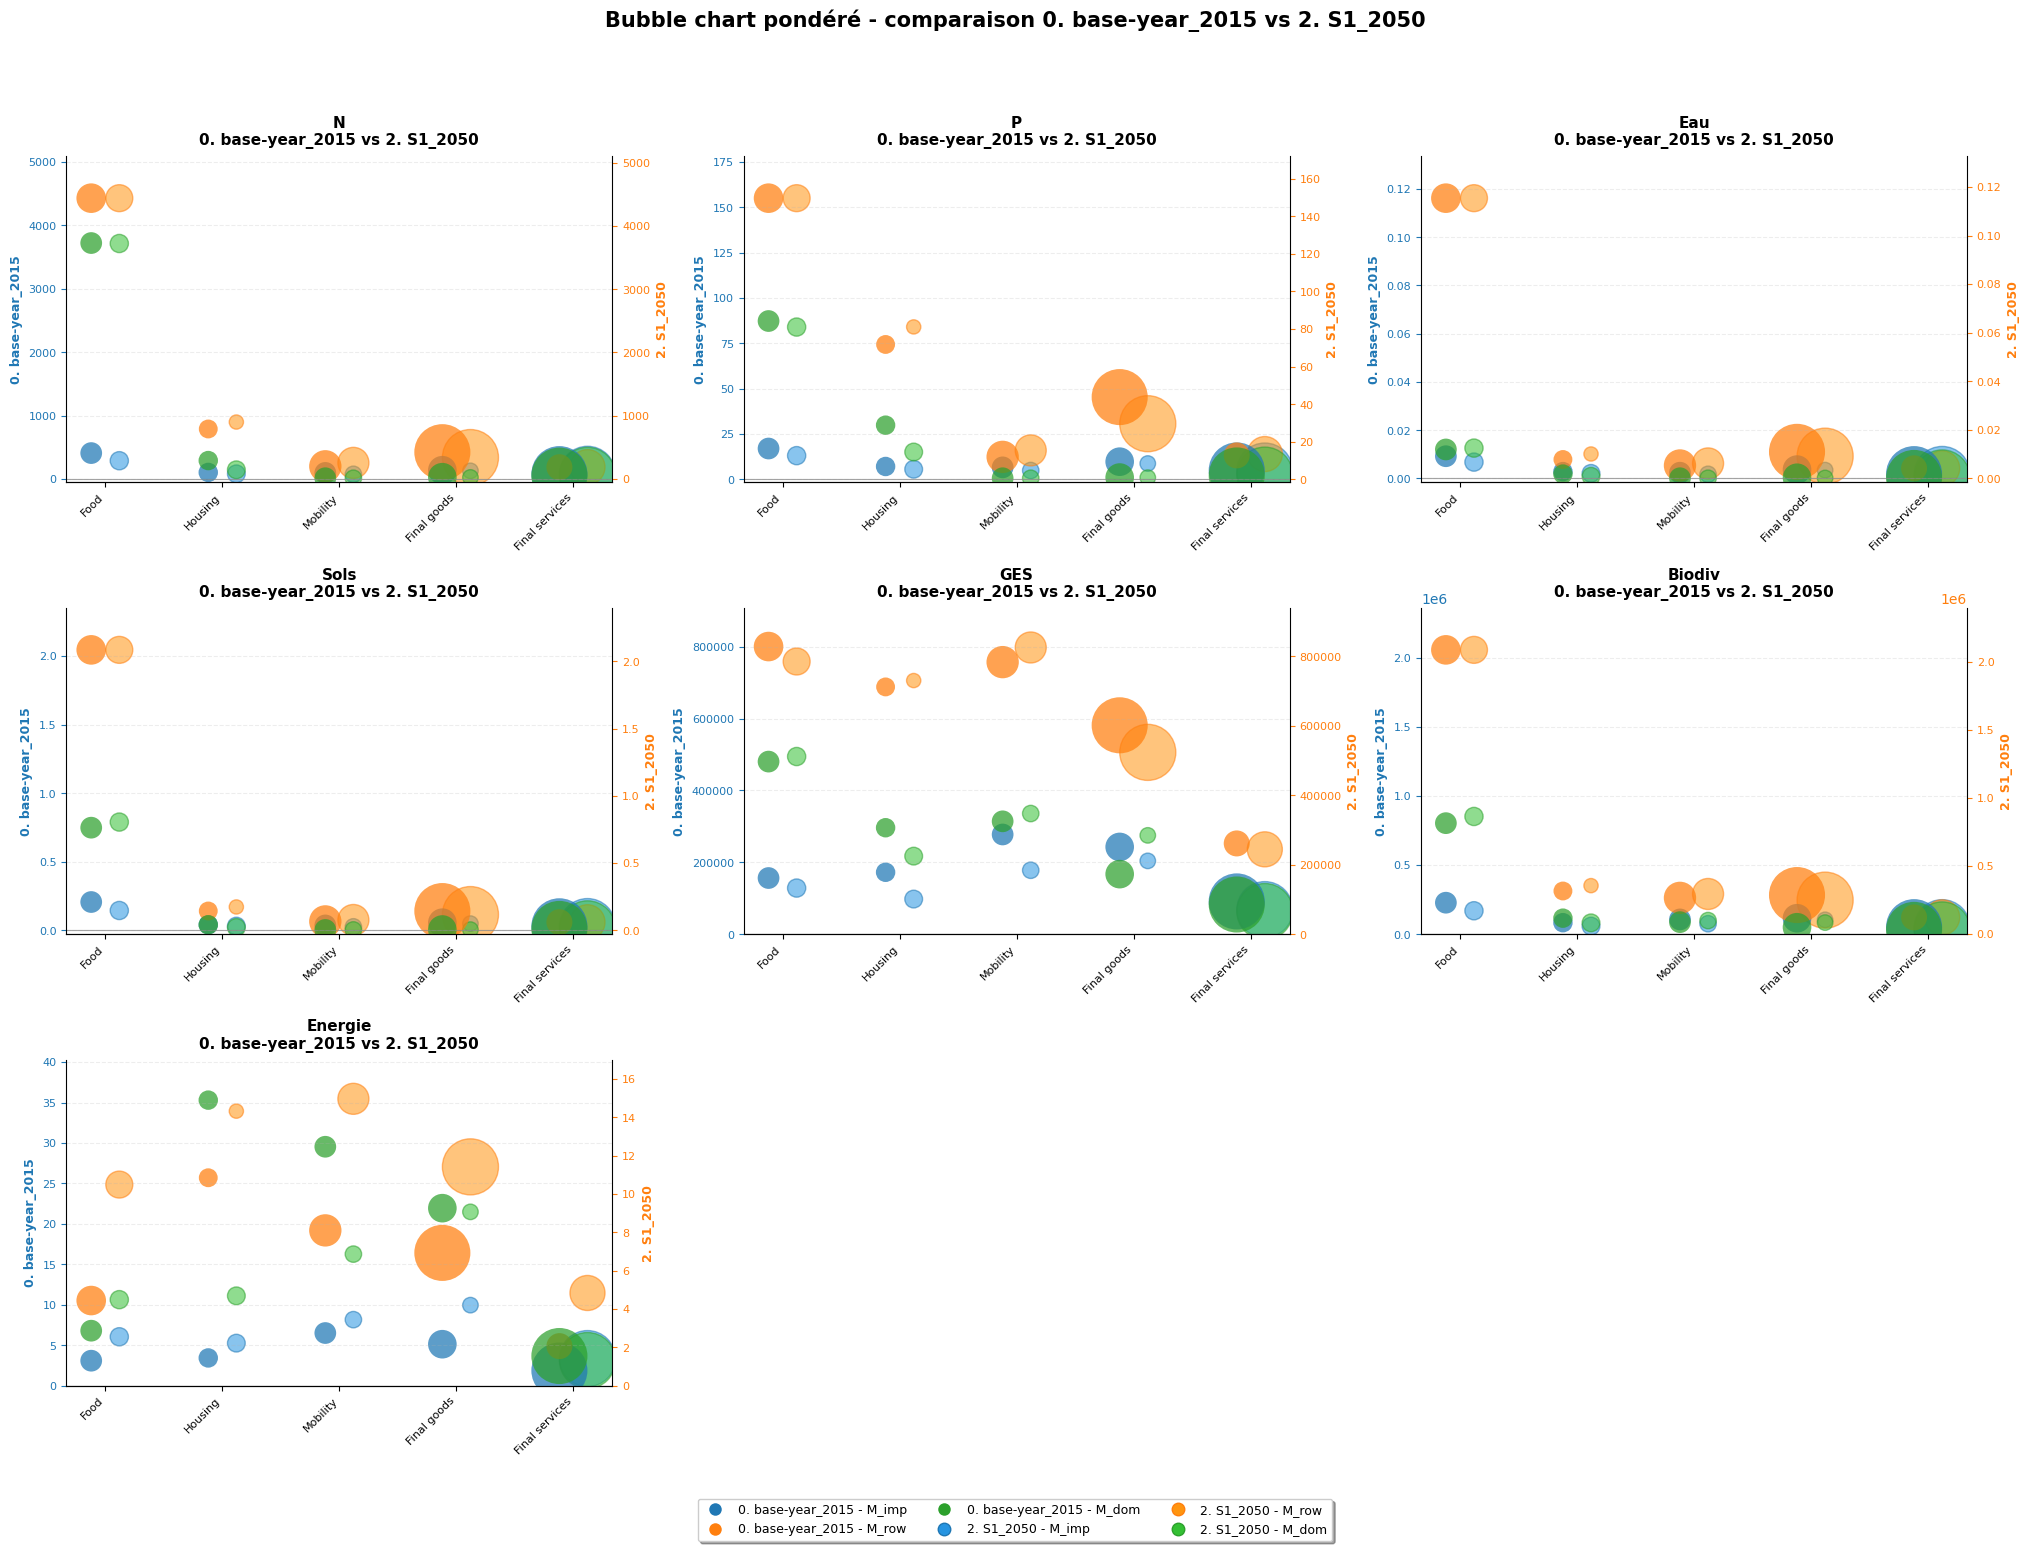

In [ ]:
# ============================================================================
# 7. BUBBLE CHART - INTENSITES PAR SOUS-PROCESSUS (BASE-YEAR VS S1)
# ============================================================================
"""
Objectif:
- 1 subplot par sous-processus
- Dans chaque subplot:
  - axe vertical gauche: scénario base-year
  - axe vertical droit: scénario S1
  - 3 bulles par catégorie pour chaque scénario

Logique de calcul:
- Bridge de la feuille 'M' (200 x 5, colonnes 4 à 8)
- Pour chaque scénario, on recalcule:
  - M_dom
  - M_imp
  - M_row
- Les tailles des bulles sont proportionnelles aux vecteurs Y du scénario considéré
"""

import math

# Facteur visuel de taille des bulles (proportionnel après normalisation)
BUBBLE_SCALE = 1600.0
BUBBLE_MIN_SIZE = 30.0


def load_bridge_m_matrix():
    """Charge le bridge 'M' (200 x 5) depuis bridge_matrices.xlsx."""
    m_raw = pd.read_excel(BRIDGE_MATRICES_FILE, sheet_name="M")

    # Colonnes 4..8 incluses -> indices 3:8
    bridge_m = m_raw.iloc[:200, 3:8].copy()

    # Index produit (3e colonne dans le fichier -> indice 2)
    bridge_m.index = m_raw.iloc[:200, 2].values

    # Conversion robuste en numérique (0/1)
    bridge_m = bridge_m.apply(pd.to_numeric, errors="coerce").fillna(0)
    bridge_m = (bridge_m > 0).astype(int)
    return bridge_m


def filter_and_weight_matrix(matrix_df, extension_factor_map):
    """Reprend le filtrage + la pondération par facteur de caractérisation."""
    weighted_rows = []
    for idx, row in matrix_df.iterrows():
        idx_value = idx[0] if isinstance(idx, tuple) else idx
        if idx_value in extension_factor_map:
            weighted_rows.append(row * extension_factor_map[idx_value])

    if not weighted_rows:
        return pd.Series(dtype=float)

    summed = pd.DataFrame(weighted_rows).sum(axis=0)
    if isinstance(summed.index, pd.MultiIndex):
        summed.index = summed.index.get_level_values(-1)
    return summed


def load_m_matrix(scenario_folder_path, lp_name, kind):
    """Charge M_k/M_RoW pour un LP et un type (dom/imp/row)."""
    if kind == "dom":
        folder = f"dom_{lp_name}"
        filename = "M_k.pkl"
    elif kind == "imp":
        folder = f"imp_{lp_name}"
        filename = "M_k.pkl"
    elif kind == "row":
        folder = f"imp_{lp_name}"
        filename = "M_RoW.pkl"
    else:
        raise ValueError("kind must be 'dom', 'imp', or 'row'")

    file_path = Path(scenario_folder_path) / "extensions" / folder / filename
    if not file_path.exists():
        return None
    return pd.read_pickle(file_path)


def get_y_blocks(reference_folder):
    """
    Charge Y.pkl et retourne les blocs 200x5 pour dom et imp.
    - y_5cols garde un format DataFrame à 5 colonnes
    - on somme bien les colonnes 0:6 de y_df comme demandé
    """
    y_path = Path(reference_folder) / "system" / "Y.pkl"
    if not y_path.exists():
        raise FileNotFoundError(f"Y.pkl not found: {y_path}")

    y_df = pd.read_pickle(y_path)

    # Somme des colonnes 0..5 (slice 0:6)
    y_sum_0_6 = y_df.iloc[:, 0:6].sum(axis=1)

    # Conserver un format DataFrame à 5 colonnes (compatible pipeline)
    y_5cols = pd.concat([y_sum_0_6] * 5, axis=1)
    y_5cols.columns = [f"Y_sum_0_6_{i+1}" for i in range(5)]

    # Découpage demandé par spécification initiale
    y_dom_5 = y_5cols.iloc[0:200].copy()
    y_imp_5 = y_5cols.iloc[200:400].copy()

    return y_dom_5, y_imp_5


def build_bridge_to_y_mapping(bridge_cols, y_cols):
    """
    Associe chaque colonne du bridge M à une colonne de Y pour les poids.
    Règles spéciales:
    - Housing -> Residential
    - Mobility -> Transport
    Fallback: correspondance positionnelle.
    """
    mapping = {}
    y_cols_l = [str(c).lower() for c in y_cols]

    def find_y_col(preferred_tokens, fallback_idx):
        for tok in preferred_tokens:
            for i, yc in enumerate(y_cols_l):
                if tok in yc:
                    return y_cols[i]
        return y_cols[min(fallback_idx, len(y_cols) - 1)]

    for i, bcol in enumerate(bridge_cols):
        b = str(bcol).lower()

        if "housing" in b:
            mapping[bcol] = find_y_col(["residential", "housing"], i)
        elif "mobility" in b or "transport" in b:
            mapping[bcol] = find_y_col(["transport", "mobility"], i)
        elif "food" in b:
            mapping[bcol] = find_y_col(["food", "nour"], i)
        else:
            mapping[bcol] = y_cols[min(i, len(y_cols) - 1)]

    return mapping


def align_series_to_bridge(vector, bridge_m):
    """Aligne un vecteur sur l'index du bridge de manière robuste."""
    vec = vector.copy()
    if len(vec) == len(bridge_m):
        vec.index = bridge_m.index
    else:
        vec = vec.reindex(bridge_m.index)
    return vec.fillna(0.0)


def weighted_mean_by_category(m_vector, y_5cols, bridge_m, bridge_to_y_col):
    """
    Calcule M agrégé par catégorie via moyenne pondérée par Y.
    Pour chaque catégorie c:
      M_c = sum_i( M_i * Y_i,col(c) * I(i in c) ) / sum_i( Y_i,col(c) * I(i in c) )
    """
    m_vec = align_series_to_bridge(m_vector, bridge_m)
    y_aligned = y_5cols.copy()
    if len(y_aligned) == len(bridge_m):
        y_aligned.index = bridge_m.index
    else:
        y_aligned = y_aligned.reindex(bridge_m.index)
    y_aligned = y_aligned.fillna(0.0)

    out = {}
    for cat in bridge_m.columns:
        mask = bridge_m[cat] == 1
        y_col = bridge_to_y_col[cat]

        weights = y_aligned.loc[mask, y_col].astype(float)
        values = m_vec.loc[mask].astype(float)

        denom = float(weights.sum())
        if denom > 0:
            out[cat] = float((values * weights).sum() / denom)
        else:
            out[cat] = 0.0

    return pd.Series(out)


def aggregate_y_for_sizes(y_5cols, bridge_m, bridge_to_y_col):
    """Construit les Y par catégorie pour dimensionner les bulles."""
    y_aligned = y_5cols.copy()
    if len(y_aligned) == len(bridge_m):
        y_aligned.index = bridge_m.index
    else:
        y_aligned = y_aligned.reindex(bridge_m.index)
    y_aligned = y_aligned.fillna(0.0)

    out = {}
    for cat in bridge_m.columns:
        mask = bridge_m[cat] == 1
        y_col = bridge_to_y_col[cat]
        out[cat] = float(y_aligned.loc[mask, y_col].sum())
    return pd.Series(out)


def compute_subprocess_m_vectors(reference_folder, facteurs_carac_df, bridge_m, y_dom_5, y_imp_5):
    """
    Calcule M_dom/M_imp/M_row agrégés pour chaque sous-processus.
    La logique est identique pour tous les scénarios, seul le dossier change.
    """
    subprocess_to_lp = get_unique_subprocesses(facteurs_carac_df)
    bridge_to_y_col = build_bridge_to_y_mapping(list(bridge_m.columns), list(y_dom_5.columns))

    data_by_subprocess = {}

    for subprocess_name, lp_list in subprocess_to_lp.items():
        agg_dom = None
        agg_imp = None
        agg_row = None

        # Filtre facteurs du sous-processus
        sub_mask = facteurs_carac_df["Sous-processus"] == subprocess_name
        sub_data = facteurs_carac_df[sub_mask]
        extension_factor_map = dict(
            zip(sub_data["Extensions exiobase"].values, sub_data["Facteurs de caractérisation"].values)
        )

        for lp_name in lp_list:
            m_dom_df = load_m_matrix(reference_folder, lp_name, "dom")
            m_imp_df = load_m_matrix(reference_folder, lp_name, "imp")
            m_row_df = load_m_matrix(reference_folder, lp_name, "row")

            if m_dom_df is None and m_imp_df is None and m_row_df is None:
                continue

            v_dom = filter_and_weight_matrix(m_dom_df, extension_factor_map) if m_dom_df is not None else pd.Series(dtype=float)
            v_imp = filter_and_weight_matrix(m_imp_df, extension_factor_map) if m_imp_df is not None else pd.Series(dtype=float)
            v_row = filter_and_weight_matrix(m_row_df, extension_factor_map) if m_row_df is not None else pd.Series(dtype=float)

            if agg_dom is None:
                agg_dom = v_dom.copy()
                agg_imp = v_imp.copy()
                agg_row = v_row.copy()
            else:
                agg_dom = agg_dom.add(v_dom, fill_value=0)
                agg_imp = agg_imp.add(v_imp, fill_value=0)
                agg_row = agg_row.add(v_row, fill_value=0)

        if agg_dom is None:
            continue

        m_dom_cat = weighted_mean_by_category(agg_dom, y_dom_5, bridge_m, bridge_to_y_col)
        m_imp_cat = weighted_mean_by_category(agg_imp, y_dom_5, bridge_m, bridge_to_y_col)
        m_row_cat = weighted_mean_by_category(agg_row, y_imp_5, bridge_m, bridge_to_y_col)

        data_by_subprocess[subprocess_name] = {
            "M_dom": m_dom_cat,
            "M_imp": m_imp_cat,
            "M_row": m_row_cat,
        }

    y_dom_cat = aggregate_y_for_sizes(y_dom_5, bridge_m, bridge_to_y_col)
    y_imp_cat = aggregate_y_for_sizes(y_imp_5, bridge_m, bridge_to_y_col)

    return data_by_subprocess, y_dom_cat, y_imp_cat


def scale_bubble_sizes(values, scale=BUBBLE_SCALE, min_size=BUBBLE_MIN_SIZE):
    """Normalise les tailles pour éviter les bulles géantes tout en gardant la proportion."""
    arr = np.asarray(values, dtype=float)
    arr = np.where(np.isfinite(arr) & (arr > 0), arr, 0.0)

    if arr.max() <= 0:
        return np.full_like(arr, min_size, dtype=float)

    rel = arr / arr.max()
    return min_size + rel * scale


def prepare_bubble_dataset(scenario_folder_path, facteurs_carac_df, bridge_m):
    """Charge Y et calcule les données Bubble Chart pour un scénario donné."""
    y_dom_5, y_imp_5 = get_y_blocks(scenario_folder_path)
    return compute_subprocess_m_vectors(
        reference_folder=scenario_folder_path,
        facteurs_carac_df=facteurs_carac_df,
        bridge_m=bridge_m,
        y_dom_5=y_dom_5,
        y_imp_5=y_imp_5,
    )


def _compute_axis_limits(series_list, default_max=1.0):
    """Retourne des limites Y avec une marge simple et robuste."""
    values = []
    for series in series_list:
        arr = np.asarray(series, dtype=float).ravel()
        arr = arr[np.isfinite(arr)]
        if arr.size:
            values.append(arr)

    if not values:
        return 0.0, default_max

    merged = np.concatenate(values)
    y_min = float(np.min(merged))
    y_max = float(np.max(merged))

    if np.isclose(y_min, y_max):
        pad = 1.0 if np.isclose(y_max, 0.0) else abs(y_max) * 0.15
    else:
        pad = max((y_max - y_min) * 0.15, 1e-6)

    lower = min(0.0, y_min - 0.10 * pad)
    upper = y_max + pad

    if np.isclose(lower, upper):
        upper = lower + default_max

    return lower, upper


def plot_bubble_chart_comparison(base_data, base_y_dom_cat, base_y_imp_cat, s1_data, s1_y_dom_cat, s1_y_imp_cat, base_label="base-year_2015", s1_label="S1_2050"):
    """Trace une figure comparative base-year vs S1, avec un axe vertical par scénario."""
    subprocesses = list(base_data.keys())
    if not subprocesses:
        print("Aucune donnée à tracer.")
        return None, None

    # On utilise l'ordre des catégories du scénario base-year et on complète si besoin avec S1.
    categories = list(dict.fromkeys(list(base_y_dom_cat.index) + list(s1_y_dom_cat.index)))
    x_pos = np.arange(len(categories))
    x_base = x_pos - 0.12
    x_s1 = x_pos + 0.12

    n_sp = len(subprocesses)
    n_cols = 3
    n_rows = int(math.ceil(n_sp / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.8 * n_cols, 5.1 * n_rows))
    axes = np.array(axes).reshape(-1)

    base_colors = {
        "M_imp": "#1f77b4",
        "M_row": "#ff7f0e",
        "M_dom": "#2ca02c",
    }
    s1_colors = {
        "M_imp": get_light_shade(base_colors["M_imp"], factor=1.25),
        "M_row": get_light_shade(base_colors["M_row"], factor=1.18),
        "M_dom": get_light_shade(base_colors["M_dom"], factor=1.20),
    }

    base_size_dom = scale_bubble_sizes(base_y_dom_cat.reindex(categories).fillna(0).values)
    base_size_imp = scale_bubble_sizes(base_y_imp_cat.reindex(categories).fillna(0).values)
    s1_size_dom = scale_bubble_sizes(s1_y_dom_cat.reindex(categories).fillna(0).values)
    s1_size_imp = scale_bubble_sizes(s1_y_imp_cat.reindex(categories).fillna(0).values)

    legend_handles = []
    legend_labels = []

    for i, sp in enumerate(subprocesses):
        ax_left = axes[i]
        ax_right = ax_left.twinx()

        # Transparence pour que les deux axes restent visibles simultanément
        ax_left.set_facecolor("none")
        ax_right.set_facecolor("none")
        ax_left.patch.set_alpha(0)
        ax_right.patch.set_alpha(0)

        # L'axe gauche passe au-dessus, mais sans masquer l'axe droit grâce à la transparence
        ax_left.set_zorder(2)
        ax_right.set_zorder(1)

        if sp not in s1_data:
            s1_payload = {
                "M_imp": pd.Series(0.0, index=categories),
                "M_row": pd.Series(0.0, index=categories),
                "M_dom": pd.Series(0.0, index=categories),
            }
        else:
            s1_payload = s1_data[sp]

        base_payload = base_data[sp]

        base_m_imp = base_payload["M_imp"].reindex(categories).fillna(0).values
        base_m_row = base_payload["M_row"].reindex(categories).fillna(0).values
        base_m_dom = base_payload["M_dom"].reindex(categories).fillna(0).values

        s1_m_imp = s1_payload["M_imp"].reindex(categories).fillna(0).values
        s1_m_row = s1_payload["M_row"].reindex(categories).fillna(0).values
        s1_m_dom = s1_payload["M_dom"].reindex(categories).fillna(0).values

        # Bulles base-year sur l'axe gauche
        ax_left.scatter(x_base, base_m_imp, s=base_size_dom, c=base_colors["M_imp"], alpha=0.72, marker="o", label=f"{base_label} - M_imp", edgecolors="none")
        ax_left.scatter(x_base, base_m_row, s=base_size_imp, c=base_colors["M_row"], alpha=0.72, marker="o", label=f"{base_label} - M_row", edgecolors="none")
        ax_left.scatter(x_base, base_m_dom, s=base_size_dom, c=base_colors["M_dom"], alpha=0.72, marker="o", label=f"{base_label} - M_dom", edgecolors="none")

        # Bulles S1 sur l'axe droit
        ax_right.scatter(x_s1, s1_m_imp, s=s1_size_dom, c=s1_colors["M_imp"], alpha=0.55, marker="o", label=f"{s1_label} - M_imp", edgecolors=base_colors["M_imp"], linewidths=1.0)
        ax_right.scatter(x_s1, s1_m_row, s=s1_size_imp, c=s1_colors["M_row"], alpha=0.55, marker="o", label=f"{s1_label} - M_row", edgecolors=base_colors["M_row"], linewidths=1.0)
        ax_right.scatter(x_s1, s1_m_dom, s=s1_size_dom, c=s1_colors["M_dom"], alpha=0.55, marker="o", label=f"{s1_label} - M_dom", edgecolors=base_colors["M_dom"], linewidths=1.0)

        # Limites Y indépendantes par scénario
        base_ymin, base_ymax = _compute_axis_limits([base_m_imp, base_m_row, base_m_dom])
        s1_ymin, s1_ymax = _compute_axis_limits([s1_m_imp, s1_m_row, s1_m_dom])
        ax_left.set_ylim(base_ymin, base_ymax)
        ax_right.set_ylim(s1_ymin, s1_ymax)

        # Habillage des axes
        ax_left.set_title(f"{sp}\n{base_label} vs {s1_label}", fontsize=11, fontweight="bold", pad=8)
        ax_left.set_xticks(x_pos)
        ax_left.set_xticklabels(categories, rotation=45, ha="right", fontsize=8)
        ax_left.set_ylabel(base_label, fontsize=9, fontweight="bold", color=base_colors["M_imp"])
        ax_right.set_ylabel(s1_label, fontsize=9, fontweight="bold", color=base_colors["M_row"])
        ax_left.tick_params(axis="y", labelsize=8, colors=base_colors["M_imp"])
        ax_right.tick_params(axis="y", labelsize=8, colors=base_colors["M_row"])
        ax_left.tick_params(axis="x", labelsize=8)
        ax_left.grid(axis="y", alpha=0.22, linestyle="--")
        ax_left.axhline(0, color="#888888", linewidth=0.8, alpha=0.5)
        ax_right.axhline(0, color="#888888", linewidth=0.8, alpha=0.5)

        # Nettoyage visuel
        ax_left.spines["top"].set_visible(False)
        ax_left.spines["right"].set_visible(False)
        ax_right.spines["top"].set_visible(False)
        ax_right.spines["left"].set_visible(False)
        ax_right.tick_params(axis="x", bottom=False, labelbottom=False)

        if i == 0:
            # Légende construite une seule fois pour éviter les doublons
            from matplotlib.lines import Line2D

            for key in ["M_imp", "M_row", "M_dom"]:
                legend_handles.append(
                    Line2D([0], [0], marker="o", linestyle="", markerfacecolor=base_colors[key], markeredgecolor="none", markersize=9, label=f"{base_label} - {key}")
                )
            for key in ["M_imp", "M_row", "M_dom"]:
                legend_handles.append(
                    Line2D([0], [0], marker="o", linestyle="", markerfacecolor=s1_colors[key], markeredgecolor=base_colors[key], markersize=9, label=f"{s1_label} - {key}")
                )
            legend_labels = [handle.get_label() for handle in legend_handles]

    for i in range(n_sp, len(axes)):
        axes[i].set_visible(False)

    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=legend_labels,
            loc="lower center",
            ncol=3,
            fontsize=9,
            bbox_to_anchor=(0.5, -0.01),
            frameon=True,
            fancybox=True,
            shadow=True,
        )

    fig.suptitle(
        f"Bubble chart pondéré - comparaison {base_label} vs {s1_label}",
        fontsize=15,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    return fig, axes


# ============================================================================
# EXECUTION
# ============================================================================
reference_folder = SCENARIO_FOLDERS[REFERENCE_SCENARIO_IDX]
s1_folder = next((folder for folder in SCENARIO_FOLDERS if "s1" in folder.name.lower()), None)

if s1_folder is None:
    raise ValueError("Impossible de trouver le scénario S1 dans SCENARIO_FOLDERS")

if "facteurs_carac_df" in globals():
    facteurs_carac_df = globals()["facteurs_carac_df"]
else:
    facteurs_carac_df = load_facteurs_carac()

# Bridge M commun aux deux scénarios
bridge_m = load_bridge_m_matrix()

# Calcul des données bubble pour base-year et S1
base_data_bubble, base_y_dom_cat, base_y_imp_cat = prepare_bubble_dataset(
    reference_folder,
    facteurs_carac_df,
    bridge_m,
)
s1_data_bubble, s1_y_dom_cat, s1_y_imp_cat = prepare_bubble_dataset(
    s1_folder,
    facteurs_carac_df,
    bridge_m,
)

print(f"Scénario base-year: {reference_folder.name}")
print(f"Scénario S1: {s1_folder.name}")
print(f"Sous-processus tracés: {len(base_data_bubble)}")
print(f"Catégories: {list(base_y_dom_cat.index)}")

fig_bubble, axes_bubble = plot_bubble_chart_comparison(
    base_data=base_data_bubble,
    base_y_dom_cat=base_y_dom_cat,
    base_y_imp_cat=base_y_imp_cat,
    s1_data=s1_data_bubble,
    s1_y_dom_cat=s1_y_dom_cat,
    s1_y_imp_cat=s1_y_imp_cat,
    base_label=reference_folder.name,
    s1_label=s1_folder.name,
)

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
output_path_bubble = Path(FIGURES_DIR) / "bubble_chart_base_year_vs_s1_weighted.png"
if fig_bubble is not None:
    fig_bubble.savefig(output_path_bubble, dpi=300, bbox_inches="tight")
    print(f"Figure sauvegardee: {output_path_bubble}")
